In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Damiano Degliotti, Daniele Melaccio

<h1>CUP - KNN</h1>
<p>Exploring the cup dataset with KNN Regressor.</p>
<hr/>

In [2]:
import importlib
import numpy as np
import cross_common as cr
import cup_common as cc
import knn_common as kc
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from cross_common import MEE,MSE,RMSE,MAE,R2,LOSS


In [3]:
importlib.reload(cc)
importlib.reload(kc)
importlib.reload(cr)

<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

<h2>Preparation</h2>

<h3>Hyperparameters</h3>

In [4]:
# The common fold strategy used trough all models
outer_cv = cr.common_fold_strategy(False)
default_krange = list(range(1, 41, 2)) # <-- it means [1, 3, 5,..., 39]
default_metric = cr.MEE
scoring = cr.Scoring(default_metric)
grid_scoring = scoring.grid_scoring #cr.common_scoring(default_metric)
scaler = RobustScaler()

default_pipe = Pipeline([
    ("scaler", scaler),
    ("model", KNeighborsRegressor())
])

#gamma_values = np.logspace(-2, 1, 5)
#gamma_values = np.logspace(0, 2, 5)
gamma_values = np.logspace(1, 1.8, 6)


default_param_grid = [
    # { # Custom functions
    #     "model__n_neighbors": default_krange,
    #     "model__weights": [kc.GaussianWeights(g) for g in gamma_values],
    #     "model__algorithm": ["brute"], # <-- as for sklearn documentation we have to use 'brute'
    #     "model__p": [1, 2],          # 1=Manhattan, 2=Euclidean
    #     "model__metric": ["minkowski"]
    # },
    { # Standard sklearn way
        "scaler": [
            StandardScaler(),
            RobustScaler(),
        ],
        "model__n_neighbors": default_krange,
        "model__weights": ["uniform"],
        "model__algorithm": ["auto"],
        "model__p": [1, 2],          # 1=Manhattan, 2=Euclidean
        "model__metric": ["minkowski"]
    }
]

# --- The metrics to compute in training ---
metrics_dict = {
    MEE: (cr.mee, min),
    MSE: (cr.mse,min),
    MAE: (cr.mae,min),
    RMSE: (cr.rmse,min),
    R2: (cr.r2,max),
    "r2_mee": (cr.r2_mee,max),
}
the_metrics = metrics_dict.keys()
# ------------------------------------------


In [5]:
print(grid_scoring)

make_scorer(neg_mean_euclidean_error, greater_is_better=False, response_method='predict')


<h3>Data Loading</h3>

In [6]:
df_train, df_test = cc.load_set()

# The train set used for model selection
X_tr, y_tr = cc.prepare_dataset(df_train)
X_ts, y_ts = cc.prepare_dataset(df_test)

#y_tr = np.delete(y_tr,[0,1],axis=1)

features_names = X_tr.columns
cr.dataset_introspection(X_tr, X_ts)

,Property,Training,Test
0,Number of samples,500,1000
1,Number of features,10,10
2,Class values,[],[]
3,Class balance,[],[]


<h3>Baseline</h3>

In [7]:
importlib.reload(cr)
model_baseline = cr.model_baseline(X_tr, y_tr, outer_cv)

----------------------------------------
Baseline: DummyRegressor()
Mean baseline: 35.79302825927734
Scorer: make_scorer(neg_mean_euclidean_error, greater_is_better=False, response_method='predict')
Raw scores: [-36.10307312 -34.5480423  -35.62013626 -35.9157486  -36.77814102]


<h3>Best Model</h3>

In [8]:
importlib.reload(cr)

gs = GridSearchCV(
    default_pipe,
    param_grid=default_param_grid,
    scoring=grid_scoring,
    cv=outer_cv,
    n_jobs=-1,
    return_train_score=True
)

gs.fit(X_tr, y_tr)
best_estimator = gs.best_estimator_
best_base_model, best_base_params = cr.extract_best_pipeline_metrics_from_grid(gs)
cr.grid_introspection(gs)

Grid summary
----------------------------------------
Total model explored: 80  splits: 5
Best params: {'model__algorithm': 'auto', 'model__metric': 'minkowski', 'model__n_neighbors': 3, 'model__p': 2, 'model__weights': 'uniform', 'scaler': StandardScaler()}
Best score: -15.74373836517334
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsRegressor(n_neighbors=3))])


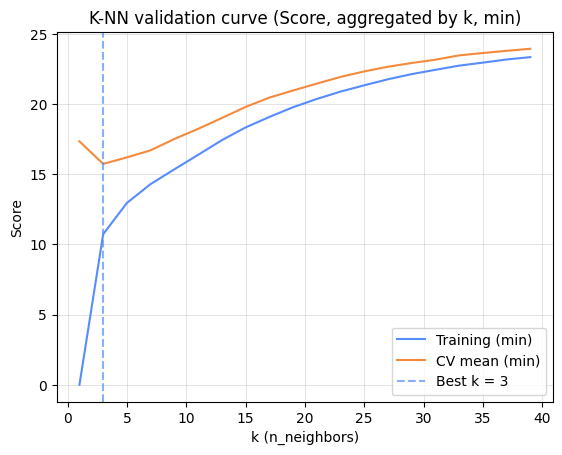

In [9]:
importlib.reload(kc)
kc.plot_knn_validation_curve_from_gs(gs,agg="min")

<h3>Learning Curve</h3>
<p>This plot shows the evolution of training and cross-validation errors as the training set size increases. The learning curve helps assess whether the model suffers from underfitting or overfitting and whether performance is limited by model capacity or by intrinsic noise in the data.</p>
<p>With distance-weighted KNN, the training error might be zero by construction, as each training point dominates its own prediction. Therefore, only the validation curve provides meaningful information about generalization.</p>

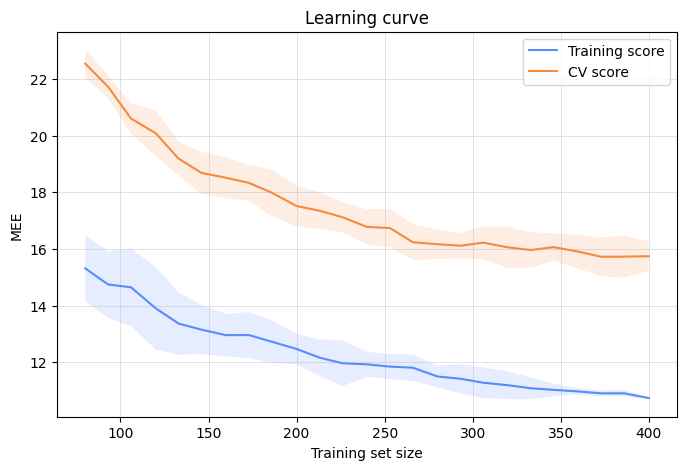

In [10]:
importlib.reload(cr)
cr.plot_learning_curve(best_estimator, X_tr, y_tr, outer_cv, scoring=grid_scoring)

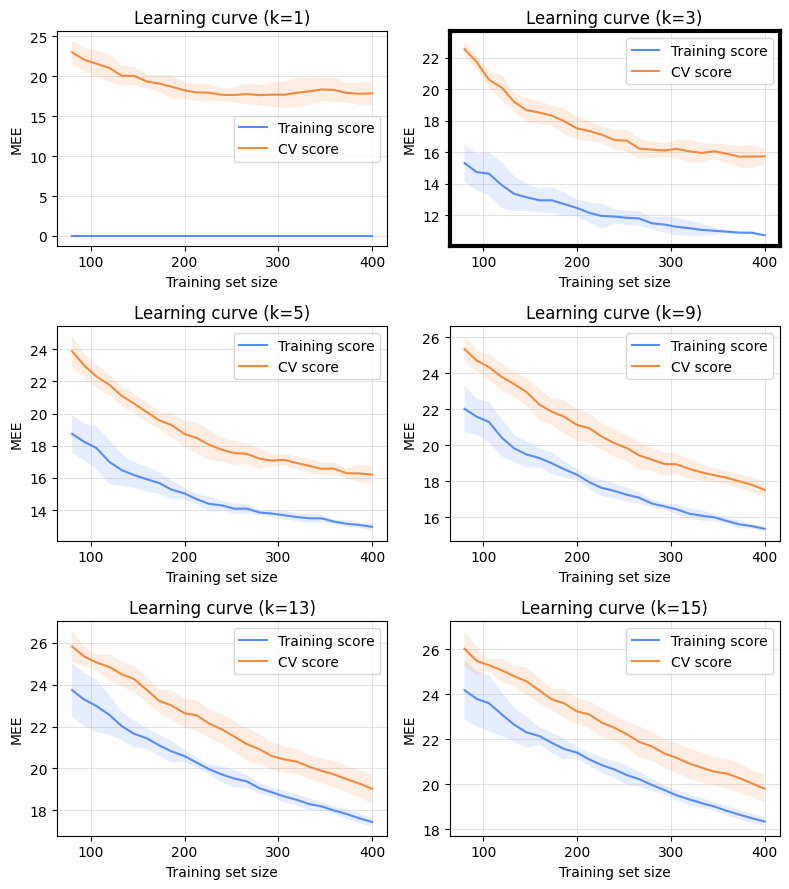

In [11]:
importlib.reload(kc)
kc.plot_knn_learning_curves_grid(
    best_estimator,
    X=X_tr,
    y=y_tr,
    cv=outer_cv,
    scoring=grid_scoring
)

<h2>Model estimation</h2>
<p>In order to display graphs and metrics, the model is rebuilt from scratch with parameters obtained from grid search, and it is then assessed trough two different approaches: non nested and nested KFold.</p>
<hr/>

<h3>Non nested Cross Validation</h3>

In [12]:
importlib.reload(cr)
non_nested_runner = cr.SklearnRegressorRunner(gs)
non_nested_result = cr.kfold(non_nested_runner, X_tr, y_tr, outer_cv, metrics=metrics_dict)

  
Perform fold: 1, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 15.0456
Validation MSE       | 85.4702
Validation MAE       | 6.7212
Validation RMSE      | 9.2450
Validation R2        | 0.7096
Validation R2_MEE    | 0.5819
Train                | samples: 400
Validation           | samples: 100
  
Perform fold: 2, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 16.1172
Validation MSE       | 94.5860
Validation MAE       | 7.1548
Validation RMSE      | 9.7255
Validation R2        | 0.6770
Validation R2_MEE    | 0.5289
Train                | samples: 400
Validation           | samples: 100
  
Perform fold: 3, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 15.6121
Validation MSE      

<p>Comparing the metrics obtained from grid search with the one originating from kfold function. They must match almost exaclty apart from sign which depends on the scoring function.</p>

In [13]:
best_idx = gs.best_index_
mean_score = gs.cv_results_["mean_test_score"][best_idx]
std_score  = gs.cv_results_["std_test_score"][best_idx]
print(f"Best CV grid score: {mean_score:.4f} ± {std_score:.4f}")
mean, std = cr.extract_mean_std(non_nested_result, f"fold_vl_{default_metric}")
print(f"Best CV func score: {mean:.4f} ± {std:.4f}")

Best CV grid score: -15.7437 ± 0.5222
Best CV func score: 15.7437 ± 0.5222


<h3>Nested Cross Validation</h3>

In [14]:
importlib.reload(cr)

inner_cv = cr.common_fold_strategy(n_split=3)
outer_cv = outer_cv

gs_inner = GridSearchCV(
    default_pipe,
    param_grid=default_param_grid,
    scoring=grid_scoring,
    cv=inner_cv,
    n_jobs=-1,
    return_train_score=True
)
nested_runner = cr.SklearnNestedRegressorRunner(gs_inner)
nested_result = cr.kfold(nested_runner, X_tr, y_tr, outer_cv, metrics=metrics_dict)

  
Perform fold: 1, train size: 400, val size: 100
Grid summary
----------------------------------------
Total model explored: 80  splits: 3
Best params: {'model__algorithm': 'auto', 'model__metric': 'minkowski', 'model__n_neighbors': 3, 'model__p': 2, 'model__weights': 'uniform', 'scaler': StandardScaler()}
Best score: -16.989858627319336
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsRegressor(n_neighbors=3))])
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 15.0456
Validation MSE       | 85.4702
Validation MAE       | 6.7212
Validation RMSE      | 9.2450
Validation R2        | 0.7096
Validation R2_MEE    | 0.5819
Train                | samples: 400
Validation           | samples: 100
  
Perform fold: 2, train size: 400, val size: 100
Grid summary
----------------------------------------
Total model explored: 80  splits: 3
Best params: {'model__algorithm': 'auto', 'mo

<h3>Results</h3>

<p>We expect that non nested KFold result shows a more optimistic views (i.e. lower metrics) in respect to nested KFold.</p>

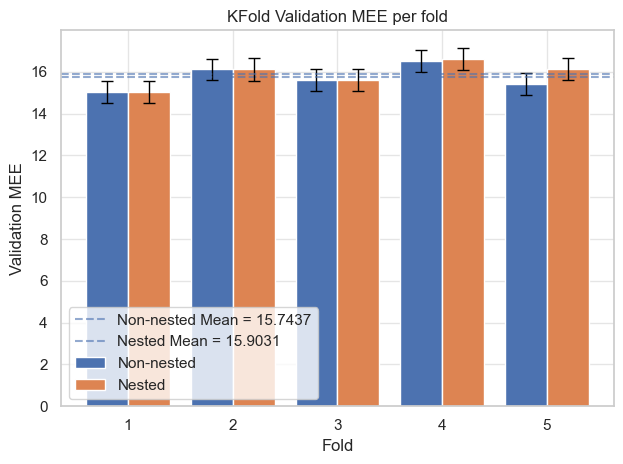

mee TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,10.695098,15.045608,4.350510
2,10.764364,16.117176,5.352812
3,10.752180,15.612110,4.859930
4,10.681774,16.597780,5.916006
5,10.860126,16.142750,5.282623
MEAN,10.750709,15.903085,5.152376
STD,0.063254,0.530247,0.523218


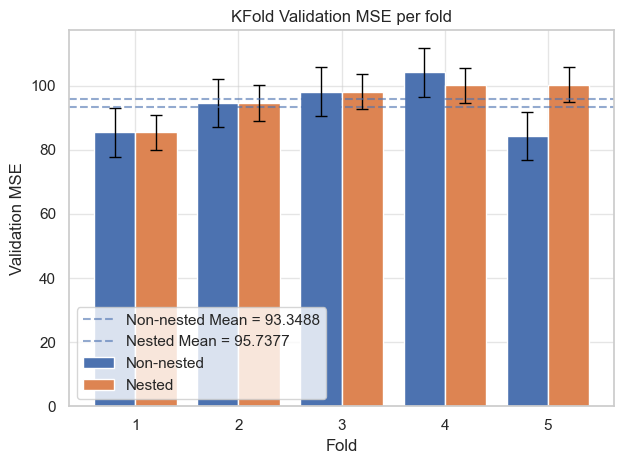

mse TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,47.203659,85.470215,38.266556
2,48.868271,94.585960,45.717690
3,48.397209,98.173042,49.775833
4,48.638000,100.133621,51.495621
5,48.173561,100.325890,52.152328
MEAN,48.256140,95.737746,47.481606
STD,0.575319,5.532707,5.122890


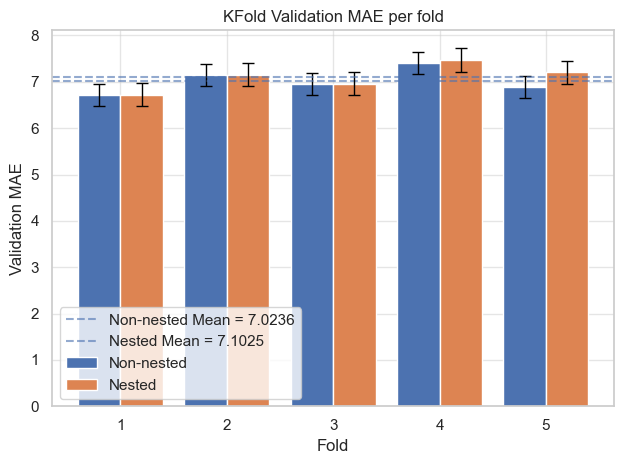

mae TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,4.760748,6.721174,1.960426
2,4.798175,7.154834,2.356659
3,4.784738,6.959048,2.174311
4,4.727578,7.471991,2.744412
5,4.860066,7.205408,2.345342
MEAN,4.786261,7.102491,2.316230
STD,0.044014,0.251332,0.257899


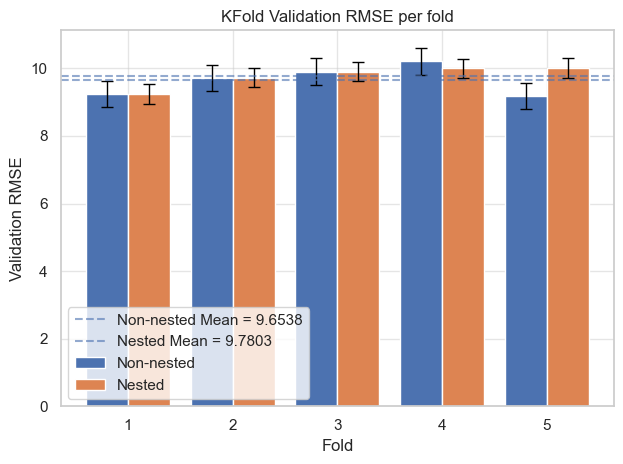

rmse TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,6.870492,9.245010,2.374518
2,6.990584,9.725531,2.734947
3,6.956810,9.908231,2.951421
4,6.974095,10.006679,3.032584
5,6.940718,10.016281,3.075564
MEAN,6.946540,9.780347,2.833807
STD,0.041526,0.287345,0.257880


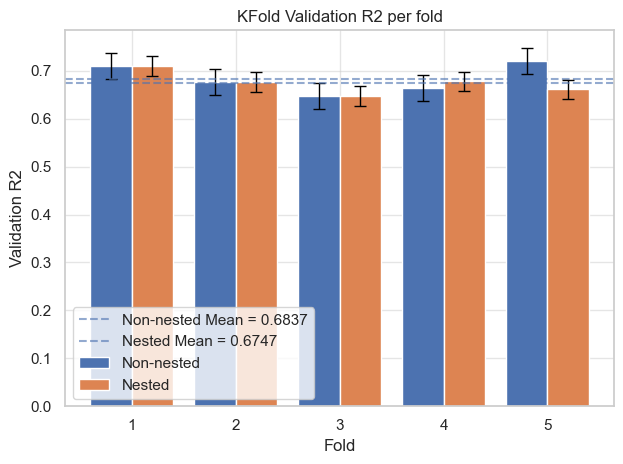

r2 TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,0.840224,0.709638,-0.130585
2,0.840766,0.677042,-0.163724
3,0.839621,0.647827,-0.191794
4,0.839780,0.677883,-0.161897
5,0.836679,0.661188,-0.175491
MEAN,0.839414,0.674716,-0.164698
STD,0.001424,0.020693,0.020115


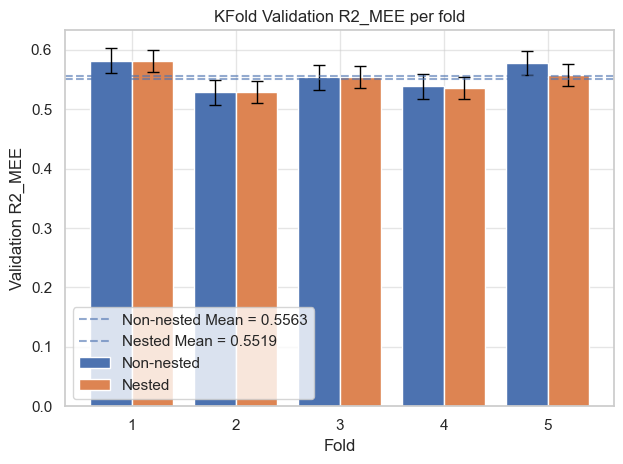

r2_mee TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,0.699731,0.581857,-0.117874
2,0.700794,0.528899,-0.171894
3,0.699818,0.554250,-0.145568
4,0.699469,0.536507,-0.162962
5,0.693838,0.558150,-0.135689
MEAN,0.698730,0.551932,-0.146798
STD,0.002487,0.018482,0.019249


In [15]:
importlib.reload(cr)
for metric in the_metrics:
    cr.plot_kfold_metric([(non_nested_result,"Non-nested"), (nested_result, "Nested")], metric)
    print(f"{metric} TR vs VL from KFold Nested results")
    display(cr.kfold_summary(nested_result, use=metric))

<h3>Bootstrap Variance</h3>
<p>Bootstrap is applied to approximate the sampling distribution of the estimator when only a finite dataset is available. By generating multiple resampled datasets, we can estimate variance, assess model stability, and better understand generalization behavior.</p>

In [16]:
importlib.reload(cr)
bootstrap_samples = 100
bootstrap_rstate = 42
samples = cr.generate_bootstrap_samples_from_dataset(X_tr, y_tr, n_samples=bootstrap_samples, random_state=bootstrap_rstate)
bootstrap_params = {"silence_output": True, "model_type":"regression"}
bootstrap_scores = cr.bootstrap_out_of_bag_scores(non_nested_runner, X_tr, y_tr, samples, metrics_fn=metrics_dict, bootstrap_params=bootstrap_params)

In [17]:
cr.aggregate_scores(bootstrap_scores)


,Metric,Mean,Std,%
0,RMSE,10.76,0.60,5.55
1,MSE,116.21,12.95,11.14
2,MAE,7.52,0.41,5.41
3,MEE,16.87,0.91,5.37
4,R2,0.61,0.04,7.15
5,R2_MEE,0.53,0.03,4.80


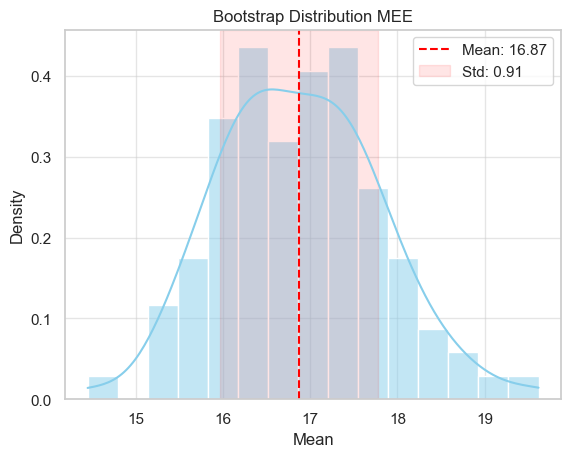

In [18]:
importlib.reload(cr)
cr.plot_bootstrap_distribution([metric[default_metric] for metric in bootstrap_scores], title=f"Bootstrap Distribution {default_metric.upper()}")

<h2>Test predictions</h2>
<hr/>

In [19]:
fitted_model = non_nested_runner.fitted_model(X_tr, y_tr)
y_pred = non_nested_runner.predict(fitted_model, X_ts)

print(y_pred)

[[ -2.5648634  -2.239299    7.169235   -5.248642 ]
 [-11.372791    2.102691  -49.053516    6.666115 ]
 [ -2.663782   -3.5217056  -3.4079058   7.1041455]
 ...
 [ -9.607278   12.796741   26.122229   -3.3910453]
 [ 19.87602     7.2052026 -15.972138   30.560715 ]
 [ -4.467525    1.4662203   9.015973   -0.6916669]]
